# Part 2 — Transformers for Astronomical Data

In this notebook we build two transformer models from scratch and train them on the ALeRCE dataset assembled in Part 1:

| Model | Input | Task |
|-------|-------|------|
| **Sequence Transformer** | Light curves `(T=60, 2 bands)` | Classify SNIa / SNIbc / SNII / SLSN |
| **Vision Transformer (ViT)** | Image stamps `(3, 63, 63)` | Classify AGN / SN / VS |

---
## 1 — Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn

from utils.data     import make_lc_loaders, make_stamp_loaders
from utils.training import fit, plot_history, get_predictions, plot_confusion_matrix

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

DATASET_DIR = Path("dataset")

Device: cpu


In [2]:
lc_train, lc_val, lc_test, LC_CLASSES = make_lc_loaders(
    DATASET_DIR / "lightcurves.npz", val_frac=0.15, test_frac=0.15, batch_size=32
)
st_train, st_val, st_test, ST_CLASSES = make_stamp_loaders(
    DATASET_DIR / "stamps.npz",      val_frac=0.15, test_frac=0.15, batch_size=32
)

x_lc, _ = next(iter(lc_train))
x_st, _ = next(iter(st_train))
print(f"LC batch shape   : {tuple(x_lc.shape)}  →  (batch, T, features)")
print(f"Stamp batch shape: {tuple(x_st.shape)}  →  (batch, channels, H, W)")
print(f"LC classes  : {LC_CLASSES}")
print(f"Stamp classes: {ST_CLASSES}")

LC batch shape   : (32, 60, 4)  →  (batch, T, features)
Stamp batch shape: (32, 3, 63, 63)  →  (batch, channels, H, W)
LC classes  : ['SNIa', 'SNIbc', 'SNII', 'SLSN']
Stamp classes: ['AGN', 'SN', 'VS']


---
## 2 — The Transformer Architecture

### Why transformers for astronomy?

Recurrent networks (RNNs, LSTMs) process sequences **step by step** — to relate an observation at day 100 to one at day 10, information must propagate through 90 hidden states. This creates a bottleneck for long-range dependencies and prevents parallelism during training.

Transformers replace recurrence with **self-attention**: every element in the sequence directly attends to every other element. A brightness measurement at day 100 can attend to the peak at day 10 in a single operation. This is natural for light curves (where classification depends on features like rise time, peak, and plateau that can be far apart) and for image stamps (where the source position relative to the host galaxy matters globally).

---

### Scaled Dot-Product Attention

Given a sequence of $T$ tokens, each a $d$-dimensional vector, we project to three matrices:

$$Q = XW_Q, \quad K = XW_K, \quad V = XW_V$$

The attention output is:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

- $QK^\top$ produces a $(T \times T)$ matrix of **compatibility scores** — how much should token $i$ attend to token $j$?
- The softmax normalises these into **attention weights** that sum to 1.
- The output is a weighted sum of the **values** $V$.
- The $\sqrt{d_k}$ scaling prevents the dot products from growing large, which would push the softmax into saturation and kill gradients.

**Multi-head attention** runs $H$ independent attention operations in parallel, each in a $d/H$-dimensional subspace. The outputs are concatenated and projected back:

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_H)\, W_O$$

Each head can learn to focus on a different aspect — one head might track the rise of the light curve, another the colour evolution across bands.

---

### Encoder Block

Each encoder block applies two sub-layers, each with a residual connection:

```
x  →  LayerNorm  →  MultiHeadAttention  →  + x
   →  LayerNorm  →  Feed-Forward (MLP)  →  + x
```

We use **Pre-LayerNorm** (normalise before each sub-layer), which is more stable than the original post-norm formulation.

---

### The [CLS] Token

Attention produces one output vector per input token — but classification needs a single fixed-size representation. The solution: **prepend a learnable [CLS] token** to the sequence. Through attention it learns to aggregate information from all other tokens. After the transformer, only the [CLS] output is fed to the classification head.

```
Input:   [CLS]  t₁  t₂  ...  tT
Output:  [CLS]' t₁' t₂' ...  tT'   ←  use only [CLS]' for classification
```

---
## 3 — Building Blocks

In [3]:
class MultiHeadAttention(nn.Module):
    """Scaled dot-product multi-head self-attention."""

    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.scale   = self.d_head ** -0.5
        self.qkv     = nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj    = nn.Linear(d_model, d_model)
        self.drop    = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        B, T, _ = x.shape

        # Project once to Q, K, V for all heads
        qkv = self.qkv(x).reshape(B, T, 3, self.n_heads, self.d_head)
        qkv = qkv.permute(2, 0, 3, 1, 4)        # (3, B, H, T, d_head)
        q, k, v = qkv.unbind(0)                  # each (B, H, T, d_head)

        # Attention weights: softmax(QKᵀ / √d_k)
        scores = (q @ k.transpose(-2, -1)) * self.scale   # (B, H, T, T)
        attn   = self.drop(scores.softmax(dim=-1))         # (B, H, T, T)

        # Weighted sum of values, then merge heads
        out = (attn @ v).transpose(1, 2).reshape(B, T, -1)  # (B, T, d_model)
        return self.proj(out), attn                          # return weights for visualization

In [4]:
class TransformerBlock(nn.Module):
    """Pre-LayerNorm Transformer encoder block (attention + FFN + residuals)."""

    def __init__(self, d_model: int, n_heads: int, ff_dim: int, dropout: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn  = MultiHeadAttention(d_model, n_heads, dropout)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, ff_dim), nn.GELU(),
            nn.Linear(ff_dim, d_model), nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        attn_out, attn_w = self.attn(self.norm1(x))
        x = x + attn_out               # residual
        x = x + self.ff(self.norm2(x)) # residual
        return x, attn_w

---
## 4 — Sequence Transformer for Light Curve Classification

Each light curve sample is a tensor of shape `(T=60, 4)`: interpolated magnitudes for g and r bands plus their binary observation masks. The architecture is:

```
(B, T, 4)  →  Linear embedding  →  (B, T, d_model)
           →  prepend [CLS]     →  (B, T+1, d_model)
           →  + positional emb. →  (B, T+1, d_model)
           →  N × TransformerBlock
           →  [CLS] output      →  Linear head  →  (B, n_classes)
```

In [5]:
class LCTransformer(nn.Module):
    """Transformer encoder for multi-band light curve classification."""

    def __init__(self, n_features: int, seq_len: int, d_model: int, n_heads: int,
                 ff_dim: int, n_layers: int, n_classes: int, dropout: float = 0.1):
        super().__init__()
        self.embedding = nn.Linear(n_features, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.randn(1, seq_len + 1, d_model) * 0.02)
        self.blocks    = nn.ModuleList([
            TransformerBlock(d_model, n_heads, ff_dim, dropout) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, n_classes)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        B = x.shape[0]
        x = self.embedding(x)                                # (B, T, d_model)
        x = torch.cat([self.cls_token.expand(B, -1, -1), x], dim=1)  # prepend [CLS]
        x = x + self.pos_embed
        attn_list = []
        for block in self.blocks:
            x, attn = block(x)
            attn_list.append(attn)
        x = self.norm(x)
        logits = self.head(x[:, 0])  # [CLS] token → classification head
        return (logits, attn_list) if return_attn else logits

In [6]:
# Hyperparameters
T          = x_lc.shape[1]   # 60 time steps
N_FEATURES = x_lc.shape[2]   # 4  (g-flux, r-flux, g-mask, r-mask)

lc_model = LCTransformer(
    n_features=N_FEATURES, seq_len=T,
    d_model=64, n_heads=4, ff_dim=128, n_layers=2,
    n_classes=len(LC_CLASSES), dropout=0.1,
).to(device)

n_params = sum(p.numel() for p in lc_model.parameters())
print(f"LCTransformer  —  {n_params:,} parameters")

LCTransformer  —  71,236 parameters


In [7]:
lc_history = fit(lc_model, lc_train, lc_val, n_epochs=60, lr=1e-3, device=device, print_every=10)

  [ 10/60]  train  loss 0.238  acc 92.19%  |  val  loss 0.313  acc 89.36%
  [ 20/60]  train  loss 0.159  acc 94.27%  |  val  loss 0.480  acc 87.23%
  [ 30/60]  train  loss 0.087  acc 97.92%  |  val  loss 0.314  acc 89.36%
  [ 40/60]  train  loss 0.014  acc 100.00%  |  val  loss 0.251  acc 91.49%
  [ 50/60]  train  loss 0.033  acc 99.48%  |  val  loss 0.226  acc 93.62%
  [ 60/60]  train  loss 0.013  acc 99.48%  |  val  loss 0.217  acc 93.62%


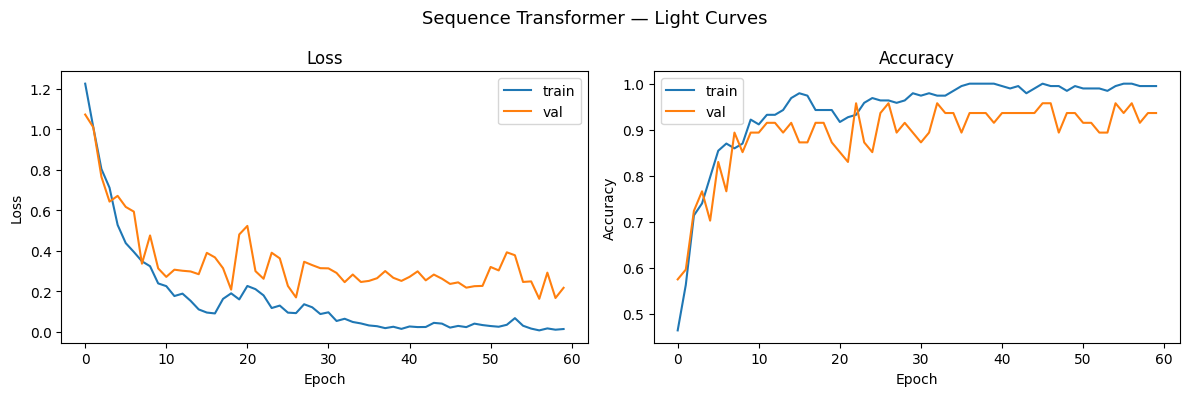

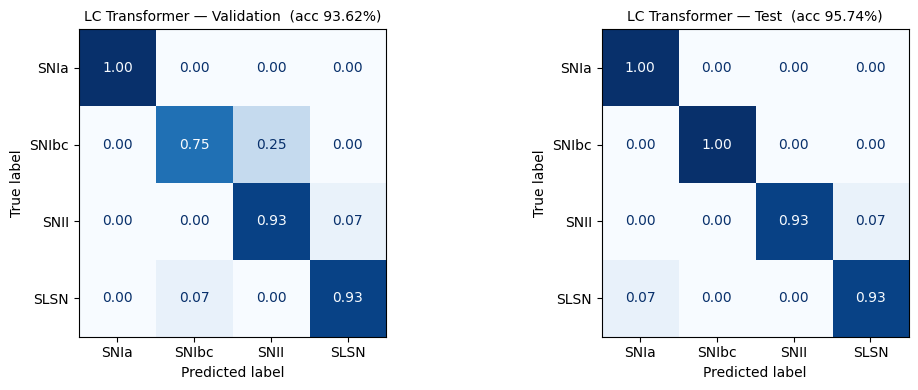

In [8]:
plot_history(lc_history, title="Sequence Transformer — Light Curves")

preds_val,  labels_val  = get_predictions(lc_model, lc_val,  device)
preds_test, labels_test = get_predictions(lc_model, lc_test, device)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
from utils.training import plot_confusion_matrix as _cm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for ax, (preds, labels, split) in zip(axes, [
    (preds_val,  labels_val,  "Validation"),
    (preds_test, labels_test, "Test"),
]):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    import numpy as np
    cm = confusion_matrix(labels, preds, normalize="true")
    ConfusionMatrixDisplay(cm, display_labels=LC_CLASSES).plot(
        ax=ax, colorbar=False, cmap="Blues", values_format=".2f"
    )
    val_acc = (preds == labels).mean()
    ax.set_title(f"LC Transformer — {split}  (acc {val_acc:.2%})", fontsize=10)
plt.tight_layout()
plt.show()

### Attention Visualization

We can inspect **what the [CLS] token attends to** in the last transformer layer. High attention weight at time step $t$ means that time step was important for classifying this object.

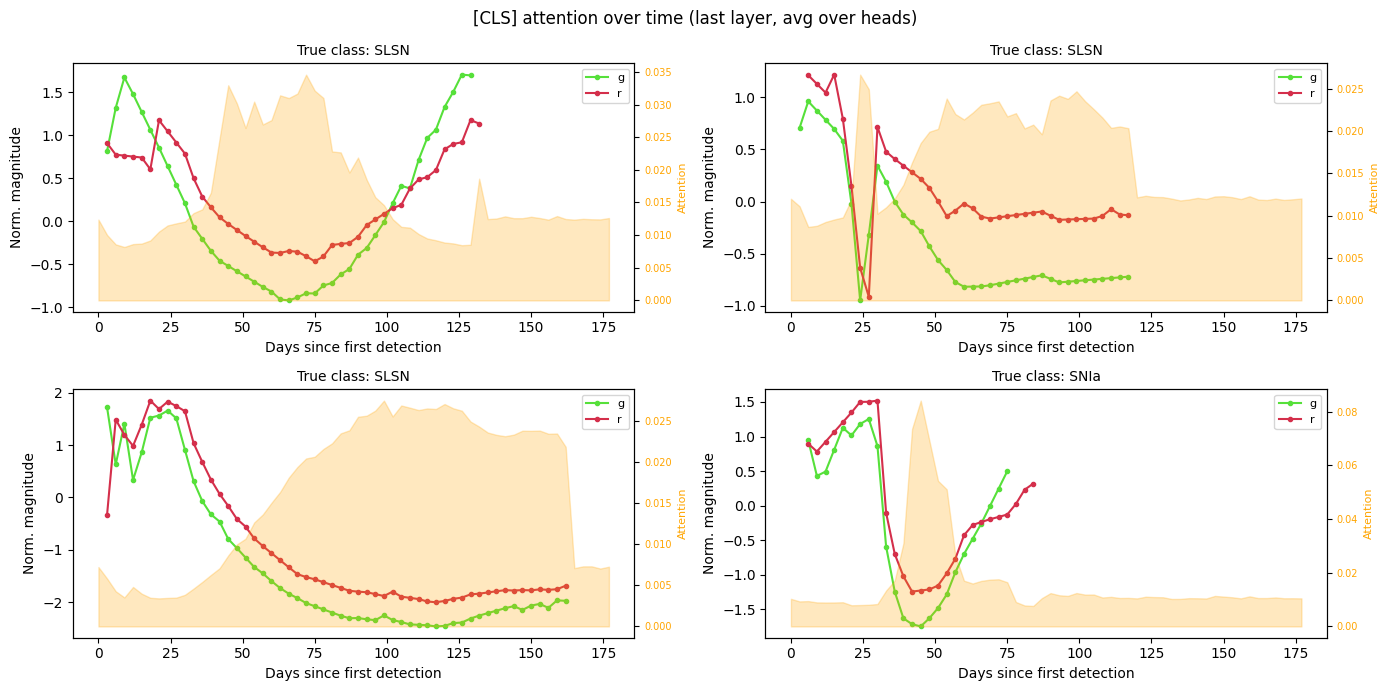

In [9]:
lc_model.eval()
x_batch, y_batch = next(iter(lc_val))

with torch.no_grad():
    _, attn_list = lc_model(x_batch.to(device), return_attn=True)

# Last-layer attention from [CLS] (position 0) to all time steps; average over heads
cls_attn = attn_list[-1][:, :, 0, 1:].mean(dim=1).cpu().numpy()  # (B, T)

COLORS = {0: "#56E03A", 1: "#D42F4B"}
BANDS  = {0: "g", 1: "r"}
times  = np.load(DATASET_DIR / "lightcurves.npz", allow_pickle=True)["times"]

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for ax, i in zip(axes.flatten(), range(4)):
    x_np = x_batch[i].numpy()          # (T, 4): [g-flux, r-flux, g-mask, r-mask]
    ax2  = ax.twinx()
    for b in range(2):
        obs = x_np[:, b + 2] == 1      # mask channel
        if obs.any():
            ax.plot(times[obs], x_np[obs, b], "o-", ms=3, color=COLORS[b], label=BANDS[b])
    ax2.fill_between(times, cls_attn[i], alpha=0.25, color="orange")
    ax2.set_ylabel("Attention", color="orange", fontsize=8)
    ax2.tick_params(axis="y", labelcolor="orange", labelsize=7)
    ax.set_title(f"True class: {LC_CLASSES[y_batch[i]]}", fontsize=10)
    ax.set_xlabel("Days since first detection")
    ax.set_ylabel("Norm. magnitude")
    ax.legend(fontsize=8)

fig.suptitle("[CLS] attention over time (last layer, avg over heads)", fontsize=12)
plt.tight_layout()
plt.show()

---
## 5 — Vision Transformer (ViT) for Stamp Classification

The ViT idea ([Dosovitskiy et al. 2020](https://arxiv.org/abs/2010.11929)): split the image into fixed-size **patches**, flatten each into a vector, project to $d_{\text{model}}$, and treat the resulting sequence exactly like tokens in a language transformer.

For our 63×63 stamps with patch size 9:

$$\text{patches} = \left(\frac{63}{9}\right)^2 = 49, \quad \text{each patch} = 9 \times 9 \times 3 = 243 \text{ features}$$

```
(B, 3, 63, 63)  →  Conv2d(patch_size=9)  →  (B, 49, d_model)    # patch embedding
               →  prepend [CLS]          →  (B, 50, d_model)
               →  + positional emb.      →  (B, 50, d_model)
               →  N × TransformerBlock
               →  [CLS] output → Linear head → (B, n_classes)
```

The **same `TransformerBlock`** we defined above is reused here — ViT and the sequence transformer share identical internal blocks. Only the input embedding differs.

In [10]:
class PatchEmbedding(nn.Module):
    """Split image into patches and project each to d_model.

    A Conv2d with kernel_size=stride=patch_size is equivalent to applying
    the same linear projection independently to each non-overlapping patch.
    """
    def __init__(self, img_size: int, patch_size: int, in_channels: int, d_model: int):
        super().__init__()
        assert img_size % patch_size == 0, "img_size must be divisible by patch_size"
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, d_model, kernel_size=patch_size, stride=patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """(B, C, H, W) → (B, N_patches, d_model)"""
        return self.proj(x).flatten(2).transpose(1, 2)


class ViT(nn.Module):
    """Vision Transformer for image stamp classification."""

    def __init__(self, img_size: int, patch_size: int, in_channels: int,
                 d_model: int, n_heads: int, ff_dim: int, n_layers: int,
                 n_classes: int, dropout: float = 0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, d_model)
        n_patches        = (img_size // patch_size) ** 2
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed   = nn.Parameter(torch.randn(1, n_patches + 1, d_model) * 0.02)
        self.blocks      = nn.ModuleList([
            TransformerBlock(d_model, n_heads, ff_dim, dropout) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, n_classes)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        B = x.shape[0]
        x = self.patch_embed(x)                               # (B, N, d_model)
        x = torch.cat([self.cls_token.expand(B, -1, -1), x], dim=1)  # prepend [CLS]
        x = x + self.pos_embed
        attn_list = []
        for block in self.blocks:
            x, attn = block(x)
            attn_list.append(attn)
        x = self.norm(x)
        logits = self.head(x[:, 0])  # [CLS] token → classification head
        return (logits, attn_list) if return_attn else logits

In [11]:
IMG_SIZE   = x_st.shape[-1]   # 63
PATCH_SIZE = 9                 # → 7×7 = 49 patches

vit_model = ViT(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=3,
    d_model=64, n_heads=4, ff_dim=128, n_layers=2,
    n_classes=len(ST_CLASSES), dropout=0.1,
).to(device)

n_params = sum(p.numel() for p in vit_model.parameters())
print(f"ViT  —  {n_params:,} parameters")
print(f"      patches: {vit_model.patch_embed.n_patches}  ({IMG_SIZE//PATCH_SIZE}×{IMG_SIZE//PATCH_SIZE} grid)")

ViT  —  85,763 parameters
      patches: 49  (7×7 grid)


In [12]:
vit_history = fit(vit_model, st_train, st_val, n_epochs=60, lr=1e-3, device=device, print_every=10)

  [ 10/60]  train  loss 0.351  acc 82.29%  |  val  loss 0.934  acc 62.79%
  [ 20/60]  train  loss 0.070  acc 97.92%  |  val  loss 1.594  acc 58.14%
  [ 30/60]  train  loss 0.160  acc 94.27%  |  val  loss 1.626  acc 60.47%
  [ 40/60]  train  loss 0.081  acc 97.92%  |  val  loss 1.524  acc 60.47%
  [ 50/60]  train  loss 0.007  acc 100.00%  |  val  loss 2.026  acc 60.47%
  [ 60/60]  train  loss 0.040  acc 98.44%  |  val  loss 2.097  acc 58.14%


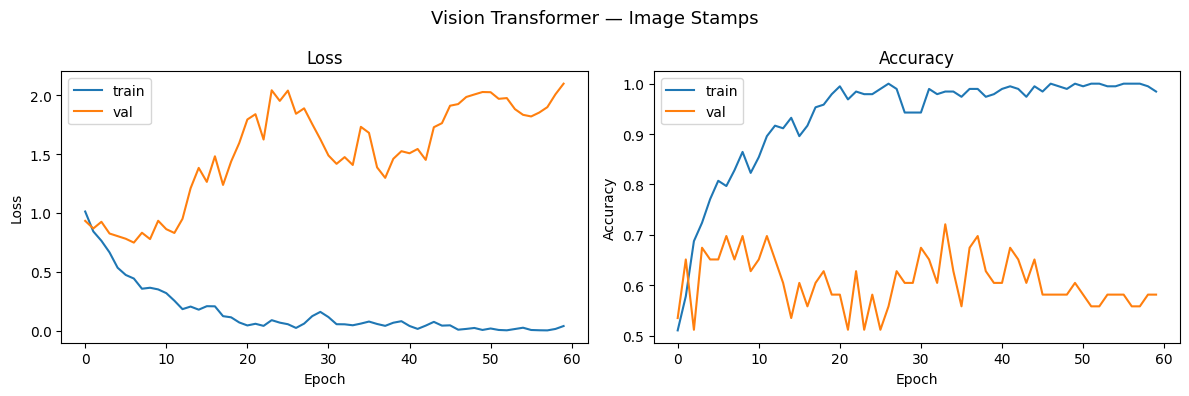

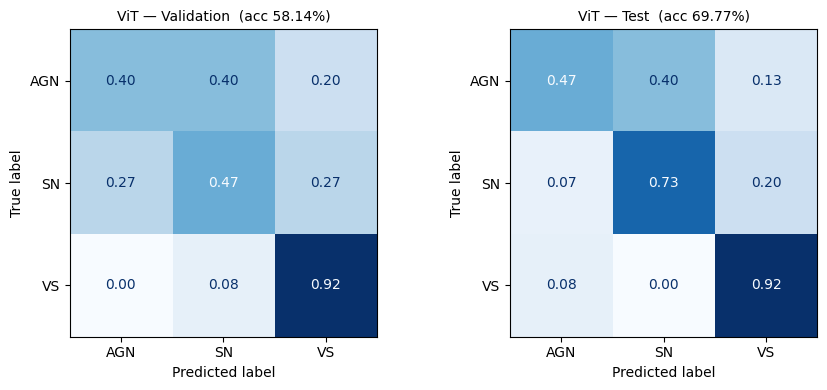

In [13]:
plot_history(vit_history, title="Vision Transformer — Image Stamps")

preds_val,  labels_val  = get_predictions(vit_model, st_val,  device)
preds_test, labels_test = get_predictions(vit_model, st_test, device)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (preds, labels, split) in zip(axes, [
    (preds_val,  labels_val,  "Validation"),
    (preds_test, labels_test, "Test"),
]):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    cm = confusion_matrix(labels, preds, normalize="true")
    ConfusionMatrixDisplay(cm, display_labels=ST_CLASSES).plot(
        ax=ax, colorbar=False, cmap="Blues", values_format=".2f"
    )
    acc = (preds == labels).mean()
    ax.set_title(f"ViT — {split}  (acc {acc:.2%})", fontsize=10)
plt.tight_layout()
plt.show()

### Attention Map Visualization

We reshape the [CLS] → patch attention weights back to the 7×7 patch grid and overlay it on the original stamp. Bright regions are the patches the model relied on most.

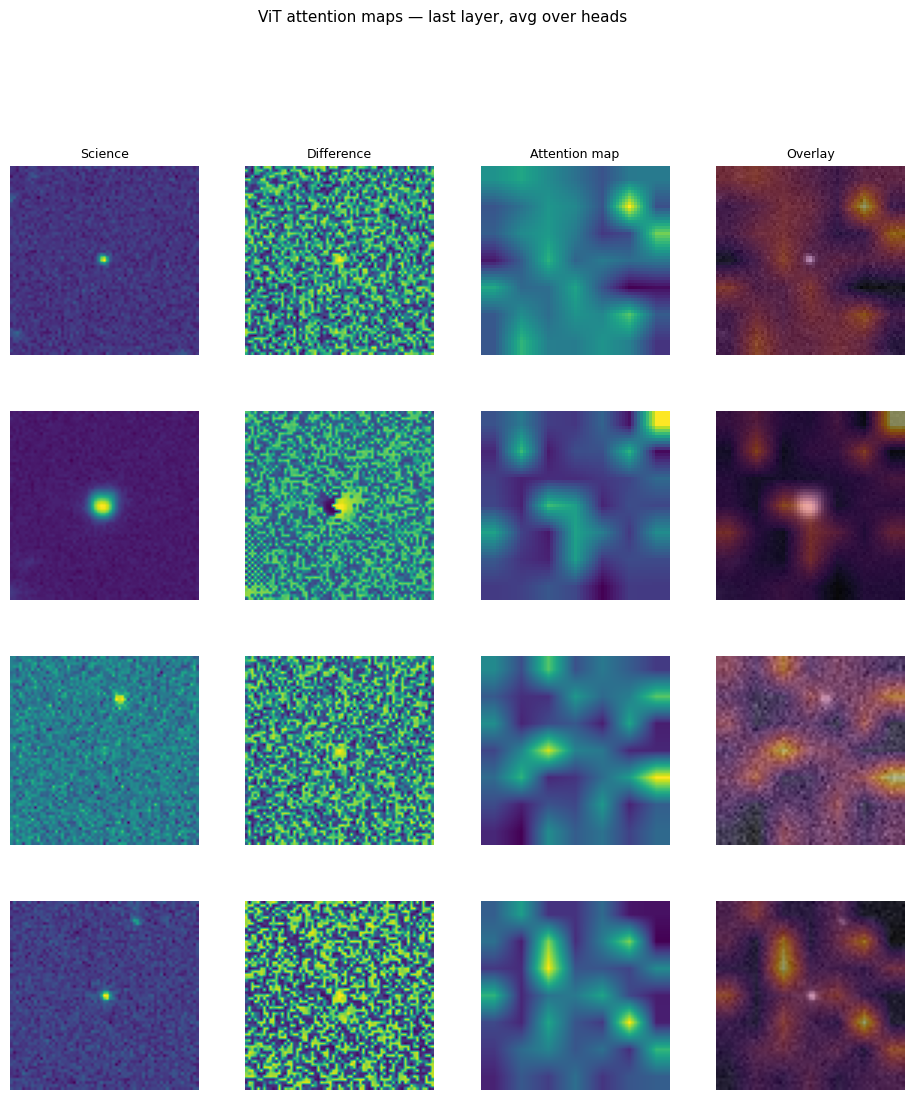

In [14]:
vit_model.eval()
x_batch, y_batch = next(iter(st_val))
n_grid = IMG_SIZE // PATCH_SIZE   # 7

with torch.no_grad():
    _, attn_list = vit_model(x_batch.to(device), return_attn=True)

# Last-layer [CLS] attention to all patches; average over heads → reshape to grid
cls_attn = attn_list[-1][:, :, 0, 1:].mean(dim=1).cpu().numpy()   # (B, N_patches)
attn_map = cls_attn.reshape(-1, n_grid, n_grid)                     # (B, 7, 7)

# Upsample attention map to stamp resolution for overlay
import torch.nn.functional as F
attn_up = F.interpolate(
    torch.tensor(attn_map).unsqueeze(1).float(),
    size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False
).squeeze(1).numpy()   # (B, 63, 63)

fig, axes = plt.subplots(4, 4, figsize=(12, 12),
                          gridspec_kw={"wspace": 0.05, "hspace": 0.3})
n_show = min(4, len(x_batch))
for i in range(n_show):
    science = np.arcsinh(x_batch[i, 0].numpy())   # science channel
    vmin, vmax = science.min(), science.max()
    for col, (img, title) in enumerate([
        (science,                          "Science"),
        (np.arcsinh(x_batch[i, 2].numpy()), "Difference"),
        (attn_up[i],                       "Attention map"),
        (science,                          "Overlay"),
    ]):
        ax = axes[i, col]
        if col < 3:
            ax.imshow(img, cmap="viridis", origin="lower")
        else:
            ax.imshow(science,    cmap="gray",   origin="lower", alpha=1.0)
            ax.imshow(attn_up[i], cmap="inferno", origin="lower", alpha=0.5)
        ax.axis("off")
        if i == 0: ax.set_title(title, fontsize=9)
        if col == 0: ax.set_ylabel(ST_CLASSES[y_batch[i]], fontsize=9,
                                    rotation=0, labelpad=40, va="center")

fig.suptitle("ViT attention maps — last layer, avg over heads", fontsize=11, y=1.01)
plt.show()